In [12]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [13]:
import os

# Your paths
train_dir = "/content/drive/MyDrive/AI and Machine Learning/Copy of devnagari digit/DevanagariHandwrittenDigitDataset/Test"
test_dir  = "/content/drive/MyDrive/AI and Machine Learning/Copy of devnagari digit/DevanagariHandwrittenDigitDataset/Train"

Training set: (3009, 784),  Labels: (3009, 10)
Test set:     (17000, 784),   Labels: (17000, 10)


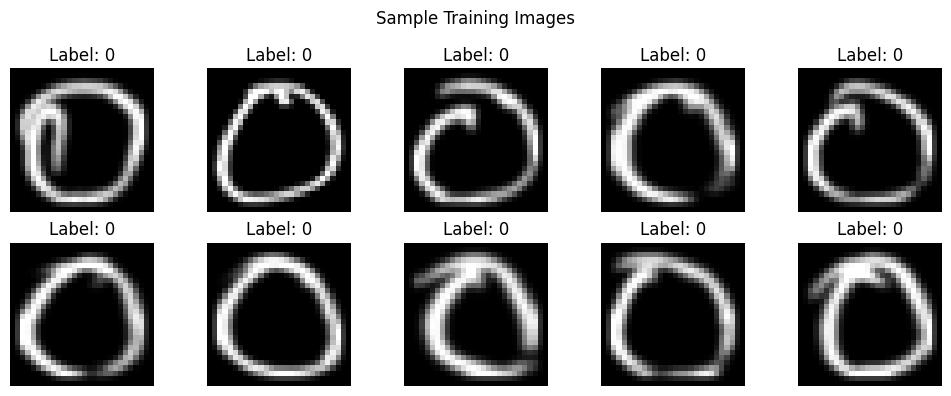

In [ ]:
import os
import numpy as np
from PIL import Image
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

img_height, img_width = 28, 28

def load_images_from_folder(folder):
    images = []
    labels = []

    class_names = sorted(os.listdir(folder))  # ['digit_0', 'digit_1', ...]
    class_map   = {name: i for i, name in enumerate(class_names)}  # {'digit_0': 0, ...}

    for class_name in class_names:
        class_path = os.path.join(folder, class_name)
        if not os.path.isdir(class_path):
            continue  # skip any stray files
        label = class_map[class_name]

        for filename in os.listdir(class_path):
            img_path = os.path.join(class_path, filename)
            img = Image.open(img_path).convert("L")    # grayscale
            img = img.resize((img_width, img_height))  # 28x28
            img = np.array(img) / 255.0                # normalize to 0-1
            images.append(img)
            labels.append(label)

    return np.array(images), np.array(labels)

# Load both splits
x_train, y_train = load_images_from_folder(train_dir)
x_test,  y_test  = load_images_from_folder(test_dir)

# Flatten 28x28 → 784
x_train = x_train.reshape(-1, 28 * 28)
x_test  = x_test.reshape(-1,  28 * 28)

# One-hot encode labels
y_train = to_categorical(y_train, num_classes=10)
y_test  = to_categorical(y_test,  num_classes=10)

print(f"Training set: {x_train.shape},  Labels: {y_train.shape}")
print(f"Test set:     {x_test.shape},   Labels: {y_test.shape}")

# Peek at some images
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i].reshape(28, 28), cmap='gray')
    plt.title(f"Label: {np.argmax(y_train[i])}")
    plt.axis("off")
plt.suptitle("Sample Training Images")
plt.tight_layout()
plt.show()

In [25]:
model = keras.Sequential([
    keras.layers.Input(shape=(784,)),
    keras.layers.Dense(64,  activation="sigmoid"),
    keras.layers.Dense(128, activation="sigmoid"),
    keras.layers.Dense(256, activation="sigmoid"),
    keras.layers.Dense(10,  activation="softmax"),
])

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

In [27]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled!")

Model compiled!


In [28]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

callbacks = [
    EarlyStopping(monitor="val_loss", patience=4, verbose=1),
    ModelCheckpoint(filepath="best_model.keras", save_best_only=True, verbose=1),
]

history = model.fit(
    x_train_s,
    y_train_s,
    batch_size=128,
    epochs=20,
    validation_split=0.2,
    callbacks=callbacks,
)

print("Training done!")

Epoch 1/20
12/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0925 - loss: 2.3694
Epoch 1: val_loss improved from None to 2.25753, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.1163 - loss: 2.3159 - val_accuracy: 0.1927 - val_loss: 2.2575
Epoch 2/20
12/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.2052 - loss: 2.2483 
Epoch 2: val_loss improved from 2.25753 to 2.14029, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.2563 - loss: 2.2137 - val_accuracy: 0.2475 - val_loss: 2.1403
Epoch 3/20
13/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4095 - loss: 2.0884 
Epoch 3: val_loss improved from 2.14029 to 1.84283, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4944 - loss: 2.0069 - val_accuracy: 0.7010 - val_los

In [29]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f"\n Test Accuracy: {test_acc:.4f}")
print(f" Test Loss:     {test_loss:.4f}")

532/532 - 1s - 2ms/step - accuracy: 0.9208 - loss: 0.2640

 Test Accuracy: 0.9208
 Test Loss:     0.2640


In [30]:
# Save
model.save("devnagari_model.h5")
print("Model saved!")

# Load
loaded_model = tf.keras.models.load_model("devnagari_model.h5")
print(" Model loaded!")

# Re-evaluate with loaded model
test_loss2, test_acc2 = loaded_model.evaluate(x_test, y_test, verbose=2)
print(f"\n Loaded Model Test Accuracy: {test_acc2:.4f}")
print(f" Loaded Model Test Loss:     {test_loss2:.4f}")

Model saved!
 Model loaded!
532/532 - 2s - 3ms/step - accuracy: 0.9208 - loss: 0.2640

 Loaded Model Test Accuracy: 0.9208
 Loaded Model Test Loss:     0.2640


In [20]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f"\n Test Accuracy: {test_acc:.4f}")
print(f" Test Loss:     {test_loss:.4f}")

532/532 - 1s - 3ms/step - accuracy: 0.9540 - loss: 0.1728

 Test Accuracy: 0.9540
 Test Loss:     0.1728


In [24]:
# Save in native Keras format instead of .h5
model.save("devnagari_model.keras")
print("Model saved in native Keras format!")

# Load it back
loaded_model = tf.keras.models.load_model("devnagari_model.keras")
print("Model loaded!")

# Re-evaluate
test_loss, test_acc = loaded_model.evaluate(x_test, y_test, verbose=2)
print(f"\n Test Accuracy: {test_acc:.4f}")
print(f"Test Loss:     {test_loss:.4f}")

Model saved in native Keras format!
Model loaded!


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 10 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


532/532 - 1s - 3ms/step - accuracy: 0.9540 - loss: 0.1728

 Test Accuracy: 0.9540
Test Loss:     0.1728


532/532 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


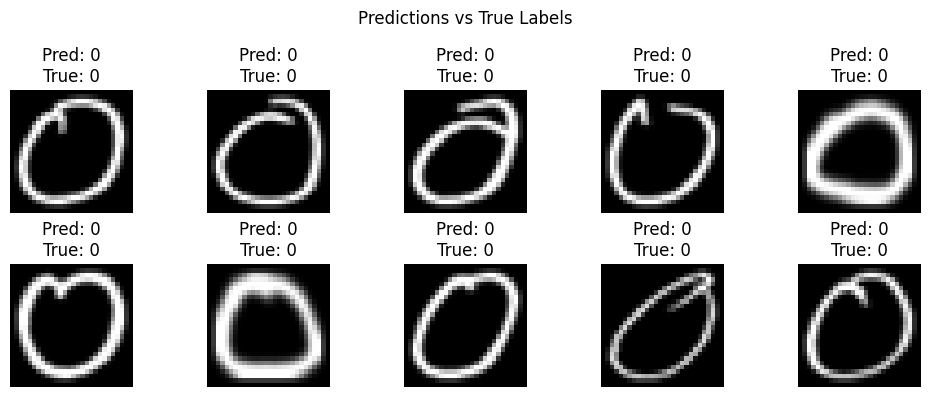

In [31]:
predictions = loaded_model.predict(x_test)
predicted_labels = np.argmax(predictions, axis=1)
true_labels = np.argmax(y_test, axis=1)

plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    plt.title(f"Pred: {predicted_labels[i]}\nTrue: {true_labels[i]}")
    plt.axis("off")
plt.suptitle("Predictions vs True Labels")
plt.tight_layout()
plt.show()

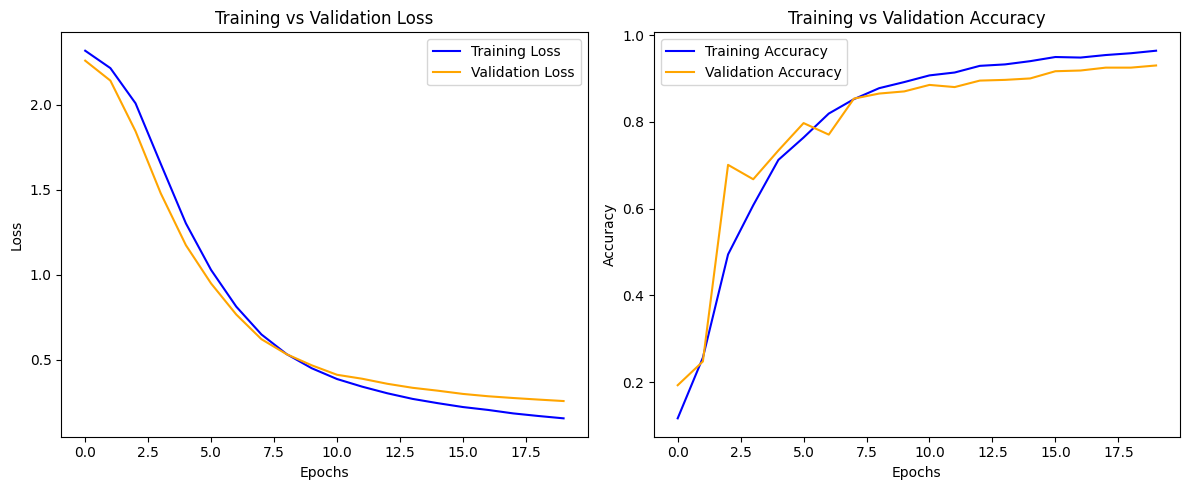

In [32]:
plt.figure(figsize=(12, 5))

# Loss plot
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'],     label='Training Loss',   color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()

# Accuracy plot
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'],     label='Training Accuracy',   color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()

plt.tight_layout()
plt.show()